In [34]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut
from numpy.linalg import eigh
from scipy.stats import pearsonr
import seaborn as sns
import os
import pandas as pd
import pickle
from PcmPy.sim import make_signal
from OptimalBattery.plot import plot_correlations
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
from matplotlib.colors import ListedColormap, to_rgb


# start with some U_true and make it arrange.logpi

In [40]:
height = 30
width = 30
K_main = 5
K_subparcels = 5
K_total = 25
theta_mu = 100

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=25, P=grid.P)
centroids = [(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [60]:
base_colors = ['red', 'green', 'blue', 'orange', 'purple']
cmap_list = []
for color in base_colors:
    base_rgb = np.array(to_rgb(color))
    for i in range(K_subparcels):
        factor = 0.6 + 0.4 * (i / (K_subparcels - 1))
        shade_rgb = base_rgb * factor + (1 - factor) * np.ones(3)
        cmap_list.append(shade_rgb)

custom_cmap = ListedColormap(cmap_list)

In [62]:
# Compute positions of all pixels
X_coords, Y_coords = np.meshgrid(np.arange(width), np.arange(height), indexing='ij')
X_coords = X_coords.flatten()
Y_coords = Y_coords.flatten()
positions = np.column_stack((X_coords, Y_coords))

# Compute distances from pixel to each centroid
D = np.zeros((grid.P, K_main))
for k, (cx, cy) in enumerate(centroids):
    D[:, k] = np.sqrt((X_coords - cx)**2 + (Y_coords - cy)**2)

# Initialize the parcel labels and define the size of each parcel
parcel_labels = np.full(grid.P, -1, dtype=int)
unassigned_nodes = set(range(grid.P))
desired_size = grid.P // K_main

for k in range(K_main - 1):
    unassigned_nodes_list = list(unassigned_nodes)
    distances = D[unassigned_nodes_list, k]
    sorted_indices = np.argsort(distances)
    nodes_to_assign = np.array(unassigned_nodes_list)[sorted_indices[:desired_size]]
    parcel_labels[nodes_to_assign] = k
    unassigned_nodes -= set(nodes_to_assign)

# Assign the remaining pixels to the last parcel
parcel_labels[list(unassigned_nodes)] = K_main - 1


# Initialize new parcel labels
new_parcel_labels = np.full(grid.P, -1, dtype=int)

for k in range(K_main):  # For each main parcel
    nodes_in_parcel = np.where(parcel_labels == k)[0]
    # Split nodes_in_parcel into K_subparcels of equal size
    subparcel_nodes = np.array_split(nodes_in_parcel, K_subparcels)
    for sub_k, nodes in enumerate(subparcel_nodes):
        new_parcel_label = k * K_subparcels + sub_k
        new_parcel_labels[nodes] = new_parcel_label

# Convert new parcel labels to a matrix U_true
U_true = np.zeros((K_total, grid.P))
for k in range(K_total):
    U_true[k, new_parcel_labels == k] = 1

# Convert U_true to torch tensor
U_true = pt.tensor(U_true, dtype=pt.float32)
arrangeT.logpi = pt.log(U_true)


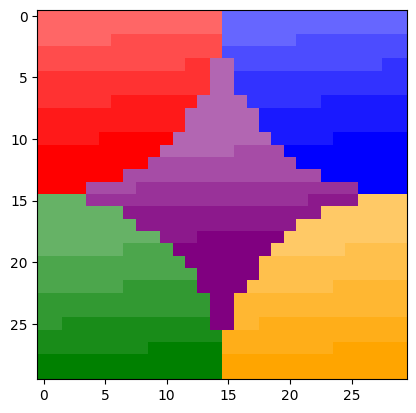

In [63]:
parcel_labels_plot = U_true.argmax(dim=0).numpy()
parcel_labels_plot = parcel_labels_plot.reshape((height, width))
plt.imshow(parcel_labels_plot, cmap=custom_cmap)

# Make Vs based on a task covariance + parcel covariance

Covarince across parcels R

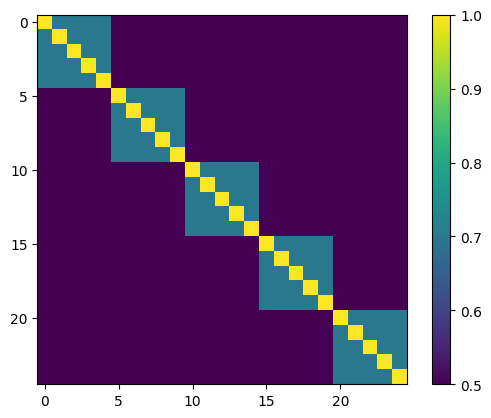

In [70]:
K_total = 25
group_size = 5
base_correlation = 0.5  
extra_correlation = 0.2  

R = np.full((K_total, K_total), base_correlation)
for i in range(0, K_total, group_size):
    R[i:i+group_size, i:i+group_size] = base_correlation + extra_correlation

np.fill_diagonal(R, 1)

plt.imshow(R)
plt.colorbar()
plt.show()


covariance across tasks G

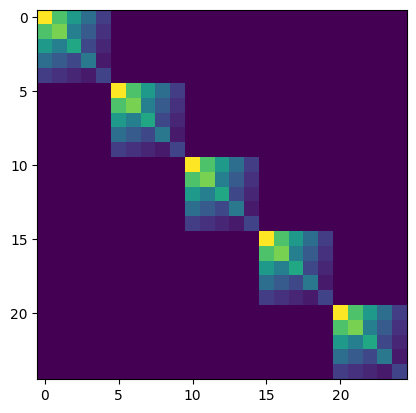

In [134]:
def custom_G(n_tasks=16, n_groups=4, group_size=4, target_corr=0.0004, variance_factors=[1.0, 0.75, 0.5, 0.25]):
    G = np.zeros((n_tasks, n_tasks))
    task_index = 0

    for group in range(n_groups):
        variances = variance_factors

        # Compute covariances based on desired correlation
        covariances = target_corr * np.outer(variance_factors, variance_factors)
        np.fill_diagonal(covariances, variances)

        # Place the block into G
        start, end = task_index, task_index + group_size
        G[start:end, start:end] = covariances

        task_index += group_size

    return G
G = custom_G(n_tasks=25, n_groups=5, group_size=5, target_corr=0.90, variance_factors=[1.0, 0.8,0.6, 0.4, 0.2])
plt.imshow(G)

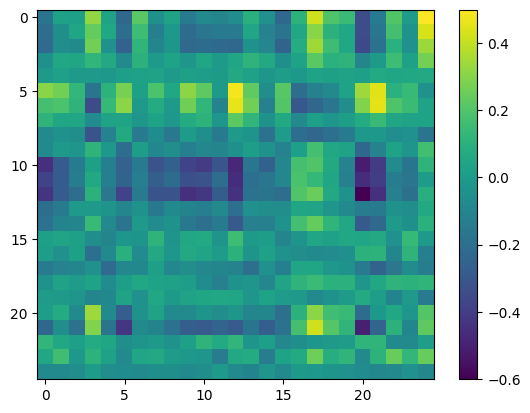

In [217]:
def make_vs(G, R, make_exact=False, rng=None):
    n_tasks = G.shape[0]
    n_parcels = R.shape[0]

    if rng is None:
        rng = np.random.default_rng()
    Vs = rng.standard_normal((n_tasks, n_parcels))

    if make_exact:
        E_row = Vs @ Vs.T
        E_col = Vs.T @ Vs
        L_col = np.linalg.cholesky(E_col)
        L_row = np.linalg.cholesky(E_row)
        Vs = np.linalg.inv(L_row) @ Vs @ np.linalg.inv(L_col)


    lam, V = np.linalg.eigh(G)
    lam[lam < 1e-15] = 0
    lam = np.sqrt(lam)
    chol_G = V * lam.reshape((1, V.shape[1]))
    Vs = (chol_G @ Vs)

    lam, V = np.linalg.eigh(R)
    lam[lam < 1e-15] = 0
    lam = np.sqrt(lam)
    chol_R = V * lam.reshape((1, V.shape[1]))
    Vs = Vs @ chol_R.T

    return Vs

Vs = make_vs(G, R, make_exact=True)


plt.imshow(Vs, aspect='auto', cmap='viridis')
plt.colorbar()
plt.show()


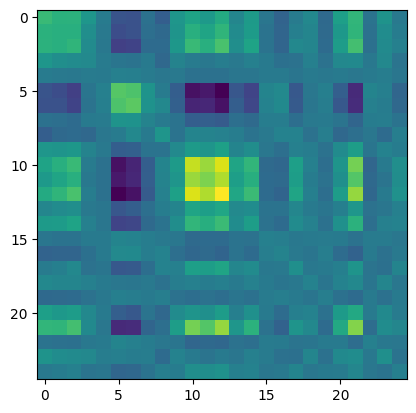

In [218]:
test = Vs @ Vs.T
plt.imshow(test)